In [11]:
# importing the file

In [26]:
import numpy as np
from astropy.stats import sigma_clipped_stats
from astropy.io import fits
import matplotlib.pyplot as plt

In [27]:
image = '../images/hlsp_ceers_jwst_nircam_nircam5_f444w_dr0.6_i2d.fits'
file = fits.open(image)

In [28]:
# checking the image structure

In [29]:
file.info()

Filename: ../images/hlsp_ceers_jwst_nircam_nircam5_f444w_dr0.6_i2d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     375   ()      
  1  SCI_BKSUB     1 ImageHDU        75   (11500, 6500)   float64   
  2  SCI           1 ImageHDU        75   (11500, 6500)   float32   
  3  ERR           1 ImageHDU        10   (11500, 6500)   float32   
  4  CON           1 ImageHDU        10   (11500, 6500, 1)   int32   
  5  WHT           1 ImageHDU         9   (11500, 6500)   float32   
  6  VAR_POISSON    1 ImageHDU         9   (11500, 6500)   float32   
  7  VAR_RNOISE    1 ImageHDU         9   (11500, 6500)   float32   
  8  VAR_FLAT      1 ImageHDU         9   (11500, 6500)   float32   
  9  BKGD          1 ImageHDU        39   (11500, 6500)   float64   
 10  BKGMASK       1 ImageHDU        41   (11500, 6500)   uint8 (rescales to int8)   
 11  HDRTAB        1 BinTableHDU    820   6R x 405C   [23A, 5A, 3A, 51A, 7A, 13A, 3A, 5A, 7A, 10A, 4A, L, 

In [30]:
sci = file["SCI"].data
err = file["ERR"].data
sci_bkgsub = file["SCI_BKSUB"].data

In [31]:
# subtracting the background by median method to exclue sky pixels from the glow of background. 

In [32]:
test = file["SCI"].data

In [33]:
wht = file["WHT"].data
nodata = (wht <= 0) | (test == 0) | ~np.isfinite(test)
print(nodata.mean())

0.5013612173913043


In [34]:
test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(6500, 11500), dtype='>f4')

In [35]:
h, w = test.shape
n_rows, n_cols = h // 50, w // 50
medians = np.zeros((n_rows, n_cols))
refined = np.zeros(sci.shape)
spreads = np.full((n_rows, n_cols), np.nan)

for i in range(n_rows):
    for j in range(n_cols):
        box      = test[i*50:(i+1)*50, j*50:(j+1)*50]
        box_mask = nodata[i*50:(i+1)*50, j*50:(j+1)*50]
        real = box[~box_mask]
        if real.size < 0.5 * box.size:
            continue                            # leave this box as NaN
        mean, med, stddev = sigma_clipped_stats(real)
        medians[i, j] = med                     # sky level of this box
        spreads[i, j] = stddev 

In [36]:
sky   = np.nanmedian(medians)      # one global sky level
noise = np.nanmedian(spreads)      # one global noise level
n = 3                              # our chosen nsigma

threshold = sky + n * noise        # "center plus n spreads" — the line we draw
suspects = (test > threshold) & ~nodata   # True where a pixel pokes above the line
print(suspects.mean())             # fraction of pixels flagged

0.022672401337792643


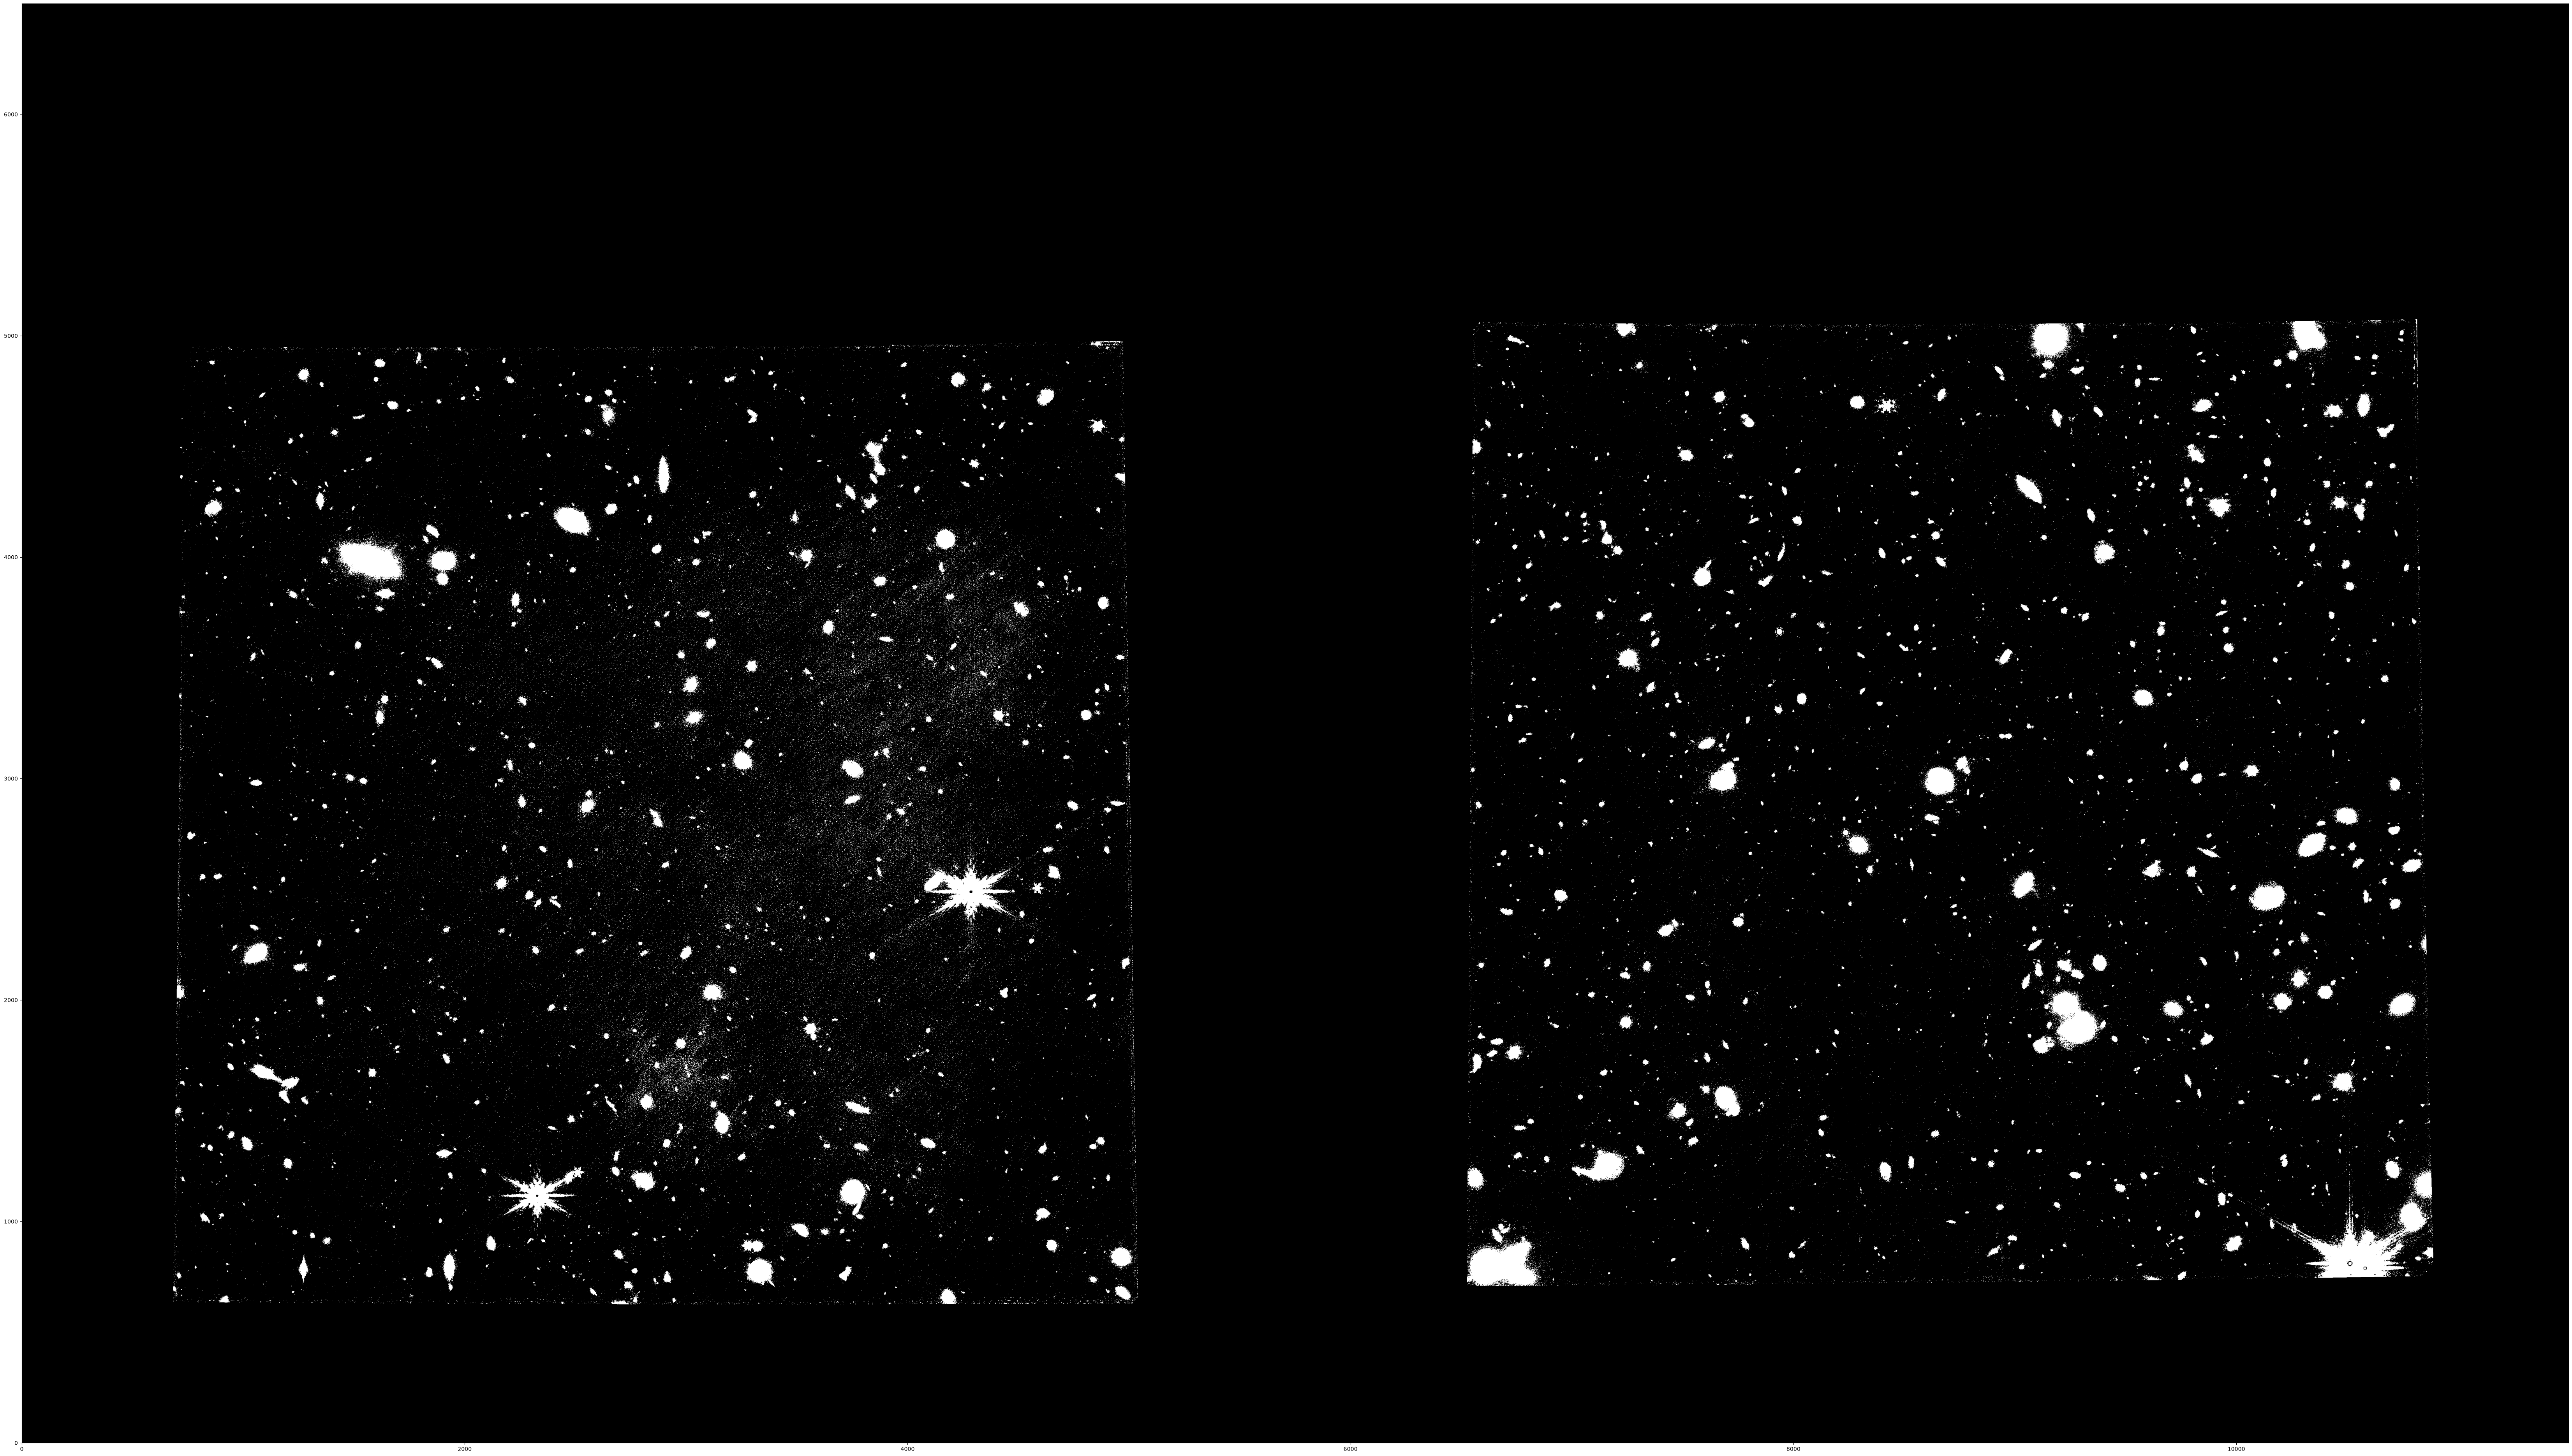

In [52]:
plt.figure(figsize=(96, 48))
plt.imshow(suspects, origin="lower", cmap="grey")
plt.show()

In [38]:
# tests

In [39]:
a = np.array([2, 3, 2, 3, 2, 3, 2, 50, 60])
b = np.array([2, 3, 2, 3, 40, 50, 55, 60, 70])
c = np.array([2, 3, 2, 4, 5, 3, 6, 50, 60])

In [40]:
np.median(a)

np.float64(3.0)

In [41]:
np.median(b)

np.float64(40.0)

In [42]:
np.median(c)

np.float64(4.0)

In [43]:
np.median(np.array([3.0, 40.0, 3.0]))

np.float64(3.0)

In [44]:
ass = test[0:50, 0:50]

In [45]:
sigma_clipped_stats(ass)

(np.float32(0.0), np.float32(0.0), np.float32(0.0))

In [46]:
ass.size

2500

In [47]:
refined.shape

(6500, 11500)